## Chains

### What and why

chains are used to create pipielines
In this the output of the one component is directt sent to second step as input wihout any manualization, and oyullyoull get the output

U can make COmplex chains as well

1. Linear
2. Parallel
3. Conditional

In [1]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os

load_dotenv()

hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

model = ChatHuggingFace(llm=llm)

prompt = PromptTemplate(
    template = 'Generate 5 interesting facts about {topic}',
    input_variables = ['topic']
)

parser= StrOutputParser()

chain = prompt | model | parser

result = chain.invoke({'topic': 'space exploration'})

print(result)

chain.get_graph().print_ascii()




c:\Users\HP\Documents\Coding journeys\GenAI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Here are 5 interesting facts about space exploration:

1. **The Voyager Golden Records**: On board the Voyager 1 and 2 spacecraft are gold-plated copper records that contain sounds and images of Earth. These records, known as the Golden Records, were designed to serve as a message to any extraterrestrial life form that might encounter the spacecraft. The records include sounds from nature, music, and human voices, as well as images of human life on Earth.

2. **The Great Attractor**: In the 1970s, astronomers discovered a region of space known as the Great Attractor, which is pulling our galaxy, the Milky Way, and many others towards it. Located about 250 million light-years away, the Great Attractor is a region of space where the gravitational pull is stronger than normal. Scientists believe that the Great Attractor is a large, unseen mass of dark matter.

3. **The Longest Spacewalk in History**: The longest spacewalk in history was performed by Russian cosmonaut Alexander Misurkin, w

## Sequential Chain

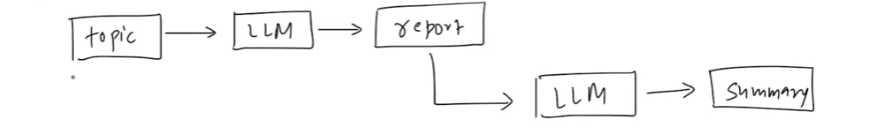

In [2]:
load_dotenv()

prompt1 = PromptTemplate(
    template = 'Generate a detailed report on {topic}',
    input_variables = ['topic']
)

prompt2 = PromptTemplate(
    template = 'Summarize the following reportin 5 pointers: {text}',
    input_variables = ['text']
)

hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

model = ChatHuggingFace(llm=llm)

parser = StrOutputParser()

chain = prompt1 | model | parser | prompt2 | model | parser

result = chain.invoke({'topic': 'Porn addiction'})

print(result)

Here are 5 key pointers summarizing the report on porn addiction:

1. **Causes of porn addiction are multifaceted**: Biological factors (hormonal imbalances, brain chemistry, and genetics), environmental factors (exposure to pornography at a young age, social media, and peer pressure), psychological factors (mental health conditions like depression, anxiety, and low self-esteem), trauma, and social and cultural factors all contribute to the development of porn addiction.

2. **Common symptoms of porn addiction include compulsive consumption, loss of control, and secrecy**: People struggling with porn addiction may spend increasing amounts of time watching pornography, feel unable to control or stop watching, and hide or lie about their consumption from others.

3. **Porn addiction has severe consequences on an individual's life**: It can lead to relationship problems, mental health issues (depression, anxiety, and suicidal thoughts), physical health problems (sleep disorders, eye strai

In [3]:
chain.get_graph().print_ascii()

     +-------------+       
     | PromptInput |       
     +-------------+       
            *              
            *              
            *              
    +----------------+     
    | PromptTemplate |     
    +----------------+     
            *              
            *              
            *              
   +-----------------+     
   | ChatHuggingFace |     
   +-----------------+     
            *              
            *              
            *              
   +-----------------+     
   | StrOutputParser |     
   +-----------------+     
            *              
            *              
            *              
+-----------------------+  
| StrOutputParserOutput |  
+-----------------------+  
            *              
            *              
            *              
    +----------------+     
    | PromptTemplate |     
    +----------------+     
            *              
            *              
            *       

## parallel chains

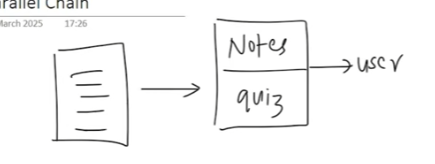

In [6]:
from langchain_core.runnables import RunnableParallel, RunnableSequence

hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

model1 = ChatHuggingFace(llm=llm)
model2 = ChatHuggingFace(llm=llm)

prompt1 = PromptTemplate(
    template = 'Generate short and simple notes from the following text: {text}',
    input_variables = ['text']
)
prompt2 = PromptTemplate(
    template = 'Generate 5 short question answers from the following text: {text}',
    input_variables = ['text'] 
)

prompt3 = PromptTemplate(
    template = 'Merge the provided notes and quiz into a single text: Notes: {notes} Quiz: {quiz}',
    input_variables = ['notes', 'quiz']
)

parser = StrOutputParser()

# we'll develop the two chains one parallel and one linear

# parallel chain

chain_parallel = RunnableParallel({
    'notes' : prompt1 | model1 | parser,
    'quiz' : prompt2 | model2 | parser
})

# linear chain merging
merge_chain = prompt3 | model1 | parser

# final chain
chain = chain_parallel | merge_chain

text = """
String theory is a theoretical framework in physics that attempts to reconcile quantum mechanics and general relativity into a single unified description of the universe. Instead of treating elementary particles such as electrons, quarks, and photons as zero-dimensional points, string theory proposes that these particles are actually tiny one-dimensional vibrating strings. The different vibrational modes of these strings correspond to different particles, much like different vibrations of a guitar string produce different musical notes.

One of the main motivations behind string theory is the incompatibility between quantum mechanics and Einstein’s theory of general relativity. Quantum mechanics successfully describes the behavior of particles at microscopic scales, while general relativity explains gravity and the large-scale structure of spacetime. However, when physicists attempt to combine the two theories under extreme conditions, such as inside black holes or during the Big Bang, mathematical inconsistencies arise. String theory seeks to eliminate these inconsistencies by replacing point particles with strings, which smooth out interactions at extremely small scales.

In string theory, the size of a string is believed to be on the order of the Planck length, approximately 1.6 × 10^-35 meters, making them impossible to observe directly with current technology. Despite their tiny size, the behavior of these strings can give rise to all known particles and forces in nature. Some versions of the theory even predict the existence of the graviton, a hypothetical particle that mediates gravity, which makes string theory one of the leading candidates for a theory of quantum gravity.

An interesting consequence of string theory is the requirement for extra dimensions beyond the familiar three dimensions of space and one dimension of time. Most versions of string theory require a total of ten or eleven dimensions for the mathematics to remain consistent. The extra dimensions are thought to be compactified or curled up into extremely small shapes that cannot be detected at ordinary energy scales. These compactified dimensions are often described using complex mathematical structures known as Calabi–Yau manifolds.

Over time, physicists discovered multiple versions of string theory, including Type I, Type IIA, Type IIB, heterotic SO(32), and heterotic E8 × E8 string theories. Later developments showed that these different theories might actually be connected through a broader framework known as M-theory. M-theory suggests the existence of higher-dimensional objects called branes in addition to strings. According to this idea, our observable universe might itself exist on a three-dimensional brane floating in a higher-dimensional space.

String theory has also influenced other areas of physics and mathematics. Concepts originating from string theory have contributed to advances in black hole thermodynamics, quantum field theory, cosmology, and pure mathematics. The AdS/CFT correspondence, proposed by Juan Maldacena in 1997, became one of the most important developments in theoretical physics because it established a relationship between gravity in higher-dimensional spaces and quantum field theories without gravity.

Despite its mathematical elegance and theoretical promise, string theory remains controversial because it currently lacks direct experimental evidence. Critics argue that many predictions of the theory occur at energy scales far beyond the reach of modern particle accelerators. Additionally, the theory allows for an enormous number of possible solutions, often referred to as the “string landscape,” making it difficult to determine which version corresponds to our universe.

Nevertheless, string theory continues to be an active area of research because it provides a framework capable of addressing some of the deepest questions in physics. Researchers hope that future advances in cosmology, particle physics, and quantum gravity may eventually provide observational evidence that supports or refutes the theory. Until then, string theory remains both one of the most ambitious and one of the most debated ideas in modern science.
"""

result = chain.invoke({'text': text})

print(result)

**Key Points of String Theory and Quiz**

1. **Overview**: A theoretical framework in physics that combines quantum mechanics and general relativity.
2. **Proposal**: Particles are one-dimensional vibrating strings, not zero-dimensional points.
3. **Motivation**: The main motivation behind string theory is to reconcile the incompatibility between quantum mechanics and general relativity.
4. **Key Features**: 
    - Strings have a size of approximately 1.6 × 10^-35 meters (Planck length).
    - Behavior of strings gives rise to all known particles and forces in nature.
    - Some versions predict the existence of the graviton, a hypothetical particle that mediates gravity.
5. **Extra Dimensions**: Most versions require 10 or 11 dimensions, with compactified or curled-up dimensions that cannot be detected at ordinary energy scales.
6. **Theories**: Multiple versions, including Type I, Type IIA, Type IIB, and M-theory, which suggests the existence of higher-dimensional objects called bran

In [7]:
chain.get_graph().print_ascii()

              +---------------------------+              
              | Parallel<notes,quiz>Input |              
              +---------------------------+              
                  ***               ***                  
               ***                     ***               
             **                           **             
+----------------+                    +----------------+ 
| PromptTemplate |                    | PromptTemplate | 
+----------------+                    +----------------+ 
          *                                   *          
          *                                   *          
          *                                   *          
+-----------------+                  +-----------------+ 
| ChatHuggingFace |                  | ChatHuggingFace | 
+-----------------+                  +-----------------+ 
          *                                   *          
          *                                   *          
          *   

## Conditional Chains 

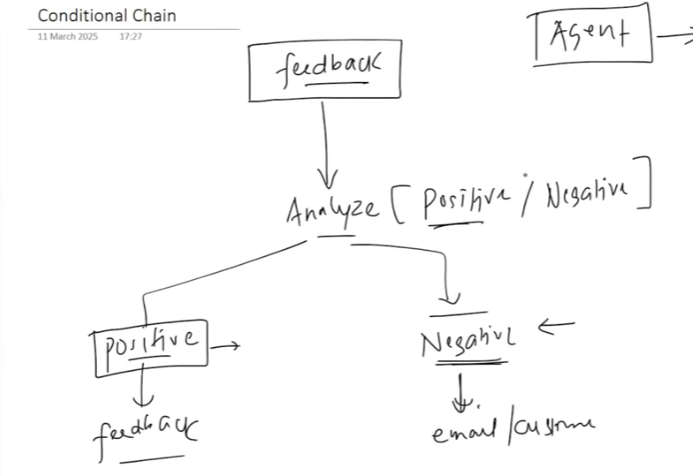

In [13]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
import os
from langchain_core.runnables import RunnableParallel, RunnableSequence, RunnableBranch,RunnableLambda
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser
from typing import Literal

class Sentiment(BaseModel):
    sentiment: Literal["positive", "negative", "neutral"] = Field(description="The sentiment classification result, which can be either 'positive', 'negative', or 'neutral'.")

parser2 = PydanticOutputParser(pydantic_object=Sentiment)

hf_token = os.getenv("HUGGINGFACEHUB_ACCESS_TOKEN")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    huggingfacehub_api_token=hf_token
)

model = ChatHuggingFace(llm=llm)

parser1 = StrOutputParser()

prompt1 = PromptTemplate(
    template = 'Classify the sentiment of the following text as positive, negative, or neutral: {feedback}, \n {format_instructions}',
    input_variables = ['feedback'],
    partial_variables = {'format_instructions': parser2.get_format_instructions()}
)

prompt2 = PromptTemplate(
    template = 'Write an approproatete response to the Positive feedback: {feedback}',
    input_variables = ['feedback'],
)

prompt3 = PromptTemplate(
    template = 'Write an approproatete response to the negative feedback: {feedback}',
    input_variables = ['feedback'],
)

prompt4 = PromptTemplate(
    template = 'Write an approproatete response to the neutral feedback: {feedback}',
    input_variables = ['feedback'],
)

text = """I recently started using this AI-powered learning platform, and overall the experience has been pretty decent. The interface is clean and easy to navigate, and the response speed is surprisingly fast compared to some other tools I’ve tried. I especially liked how the system explains technical concepts in simple language without making the answers feel overly dumbed down.

One thing that stood out positively was the contextual understanding. Even when I asked follow-up questions with incomplete sentences, the model was able to maintain context correctly most of the time. The code generation capabilities were also useful, especially for Python and C++ examples.

That said, there are still a few areas that could improve. Sometimes the responses become unnecessarily verbose, while in other cases important details are skipped. I also noticed occasional inconsistencies in technical explanations, particularly with newer frameworks and libraries. The formatting in long outputs can sometimes look cluttered as well.

A feature I would love to see in the future is better project-level memory and deeper integration with development tools like VS Code, GitHub, and Docker environments. Real-time debugging assistance inside IDEs would make the workflow much smoother for developers and students alike.

Overall, I’d say the platform is genuinely helpful and has a lot of potential. It’s already strong for learning, brainstorming, and productivity tasks, but with better consistency and tooling support, it could become an essential everyday assistant for technical work."""

classifier_chain = prompt1 | model | parser2

branchChain = RunnableBranch(
    (lambda x : x.sentiment == 'positive', prompt2 | model | parser1),
    (lambda x : x.sentiment == 'negative', prompt3 | model | parser1),
    (lambda x : x.sentiment == 'neutral', prompt4 | model | parser1),
    
    RunnableLambda(lambda x : "Invalid sentiment classification result") # as this lambda function is not a chain we have to convert it into a runnablelambda
)

chain = classifier_chain | branchChain

result = chain.invoke({'feedback': text})
print(result)

**Neutral Feedback Response**

Dear [Feedback Provider's Name],

Thank you for taking the time to share your thoughts and feedback about your experience. We appreciate your candid response and value your input in helping us improve.

We understand that our product/service may not have met your expectations in every way, and we're sorry that we didn't quite hit the mark. We're constantly striving to provide the best possible experience for our users, and your feedback will be instrumental in helping us identify areas for growth and improvement.

Could you please elaborate on what specifically didn't meet your expectations? Your insights will be invaluable in helping us refine our approach and better serve our customers in the future.

Thank you again for your feedback. We're committed to providing the highest level of quality and satisfaction, and we look forward to the opportunity to serve you better in the future.

Best regards,
[Your Name]

**Alternative Response**

Hi [Feedback Prov

In [14]:
chain.get_graph().print_ascii()

    +-------------+      
    | PromptInput |      
    +-------------+      
            *            
            *            
            *            
   +----------------+    
   | PromptTemplate |    
   +----------------+    
            *            
            *            
            *            
  +-----------------+    
  | ChatHuggingFace |    
  +-----------------+    
            *            
            *            
            *            
+----------------------+ 
| PydanticOutputParser | 
+----------------------+ 
            *            
            *            
            *            
       +--------+        
       | Branch |        
       +--------+        
            *            
            *            
            *            
    +--------------+     
    | BranchOutput |     
    +--------------+     
